In [2]:
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def read_json_file(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [5]:
def update_word_stats(word_stats: dict, entry):
    for context, data in entry.items(): # 'context' is one of [ab, xb, ax, xx]
        processed_tokens = data["processed_tokens"]
        critical_surprisal = data["critical_surprisal"]
        
        unique_words = set(processed_tokens)  # avoid duplicates
        
        for word in unique_words:
            if context not in word_stats[word]:
                word_stats[word][context] = []
            # store c-surprisals by context
            word_stats[word][context].append(critical_surprisal)

def calculate_statistics(word_stats: dict):
    word_statistics = {}
    for word, contexts in word_stats.items():
        word_statistics[word] = {}
        for context, values in contexts.items():
            mean = np.mean(values)
            std_dev = np.std(values)
            # store stats by context
            word_statistics[word][context] = (mean, std_dev, len(values))
    return word_statistics

# these do same thing as in simple_itemwise.ipynb
def itemwise_analyze_folder(folder_path):
    word_stats = defaultdict(lambda: defaultdict(list)) 
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            file_path = os.path.join(folder_path, filename)
            json_data = read_json_file(file_path)
            
            for entry in json_data:
                update_word_stats(word_stats, entry)
                
    word_statistics = calculate_statistics(word_stats)
    
    sorted_word_stats = {}
    for word, contexts in word_statistics.items():
        sorted_word_stats[word] = sorted(contexts.items(), key=lambda x: x[1][0], reverse=True)
    
    return sorted_word_stats

def itemwise_analyze_json(file_path):
    word_stats = defaultdict(lambda: defaultdict(list))
    
    if file_path.endswith(".json"):
        json_data = read_json_file(file_path)
        
        for entry in json_data:
            update_word_stats(word_stats, entry)
            
    word_statistics = calculate_statistics(word_stats)
    
    sorted_word_stats = {}
    for word, contexts in word_statistics.items():
        sorted_word_stats[word] = sorted(contexts.items(), key=lambda x: x[1][0], reverse=True)
    
    return sorted_word_stats

In [7]:
def plot_word_stats(word_stats, title):
    # order matches json order
    contexts = ['s_ab', 's_xb', 's_ax', 's_xx']
    max_mean = -float('inf') # for scaling 

    # 4 subplots
    fig, axes = plt.subplots(1, len(contexts), figsize=(20, 6), sharey=True)
    if len(contexts) == 1:
        axes = [axes] # unpack, shouldn't ever happen
    
    context_data = {}
    
    # get stats into context_data
    for i, context in enumerate(contexts):
        words = []
        means = []
        std_devs = []
        for word, context_list in word_stats.items():
            for context_key, (mean, std_dev, _) in context_list:
                if context_key == context:
                    words.append(word)
                    means.append(mean)
                    std_devs.append(std_dev)
                    max_mean = max(max_mean, mean)
        
        context_data[context] = (words, means, std_devs)
    
    # for each context make a fairly standard plot, there *will* be missing words since some words only happen as fillers/gaps
    for i, context in enumerate(contexts):
        words, means, std_devs = context_data[context]
        
        axes[i].barh(words, means, color='skyblue', xerr=std_devs, capsize=2, error_kw={'linewidth': 0.5, 'alpha': 0.8})
        axes[i].set_xlabel('Mean Critical Surprisal')
        axes[i].set_title(f'{title}: {context}')
        
        axes[i].set_xlim(0, max_mean * 1.1)
        
        axes[i].grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.7)

    fig.suptitle(f'{title}: Words vs. Mean Critical Surprisal by Context', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


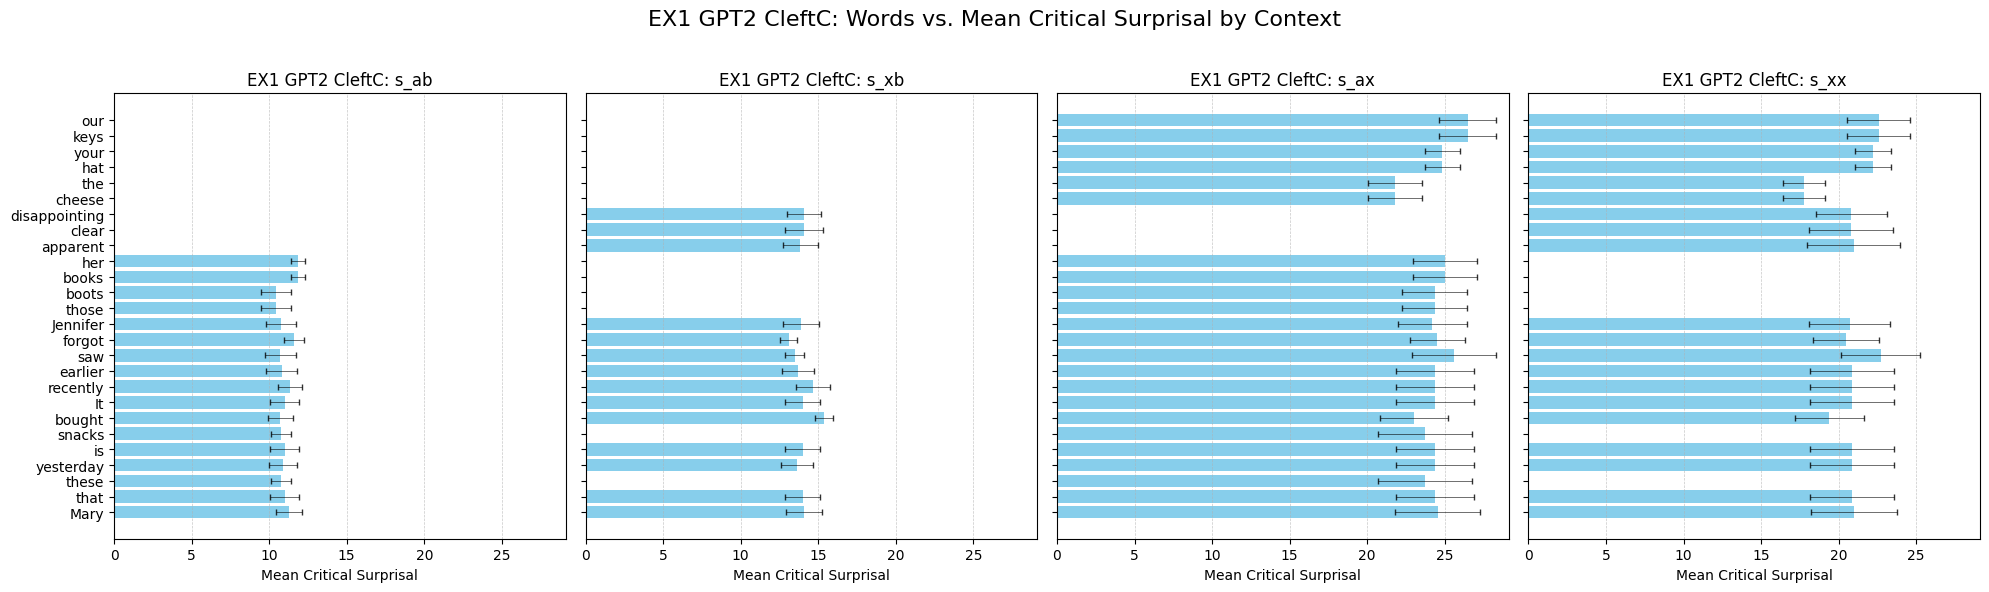

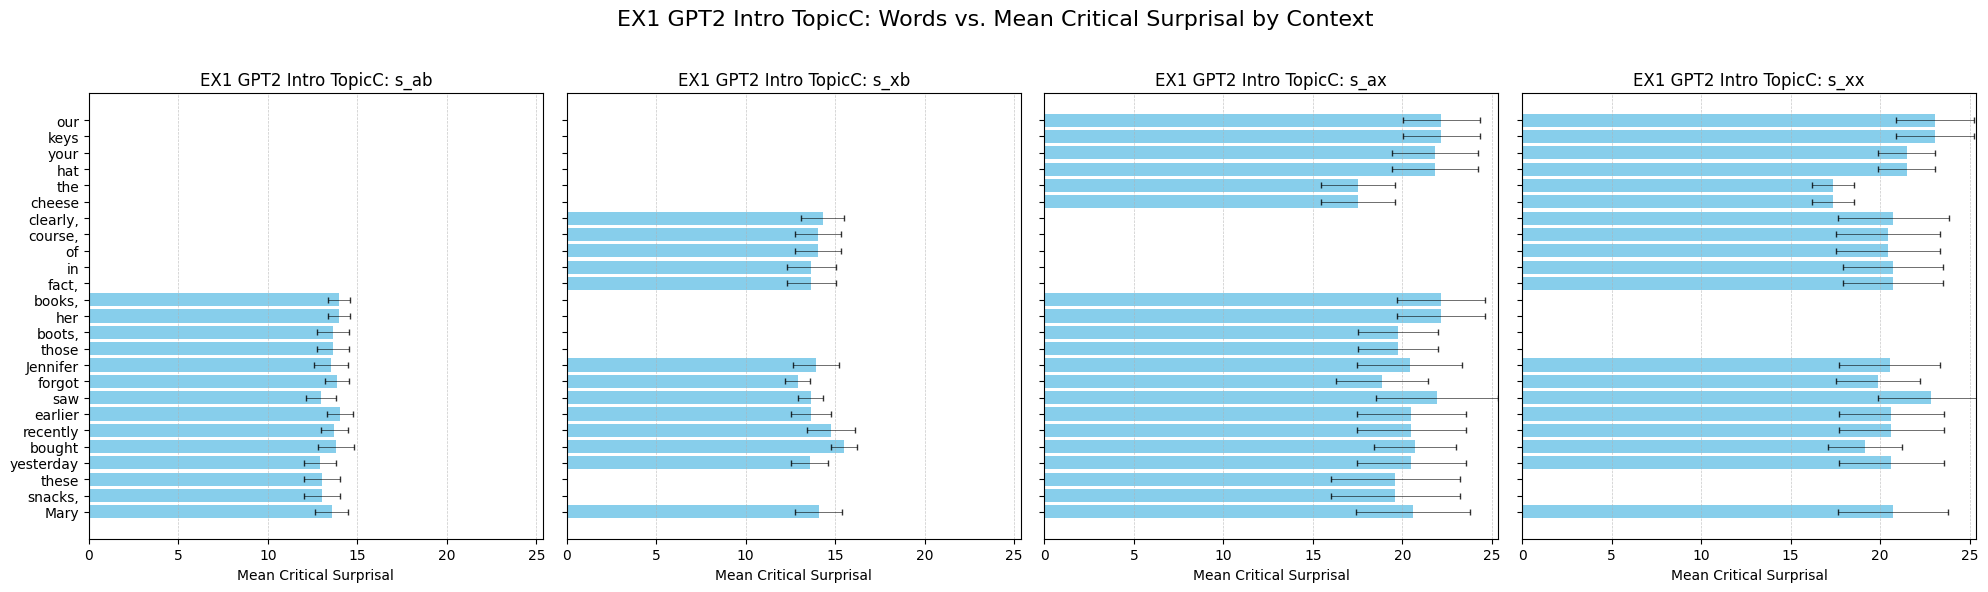

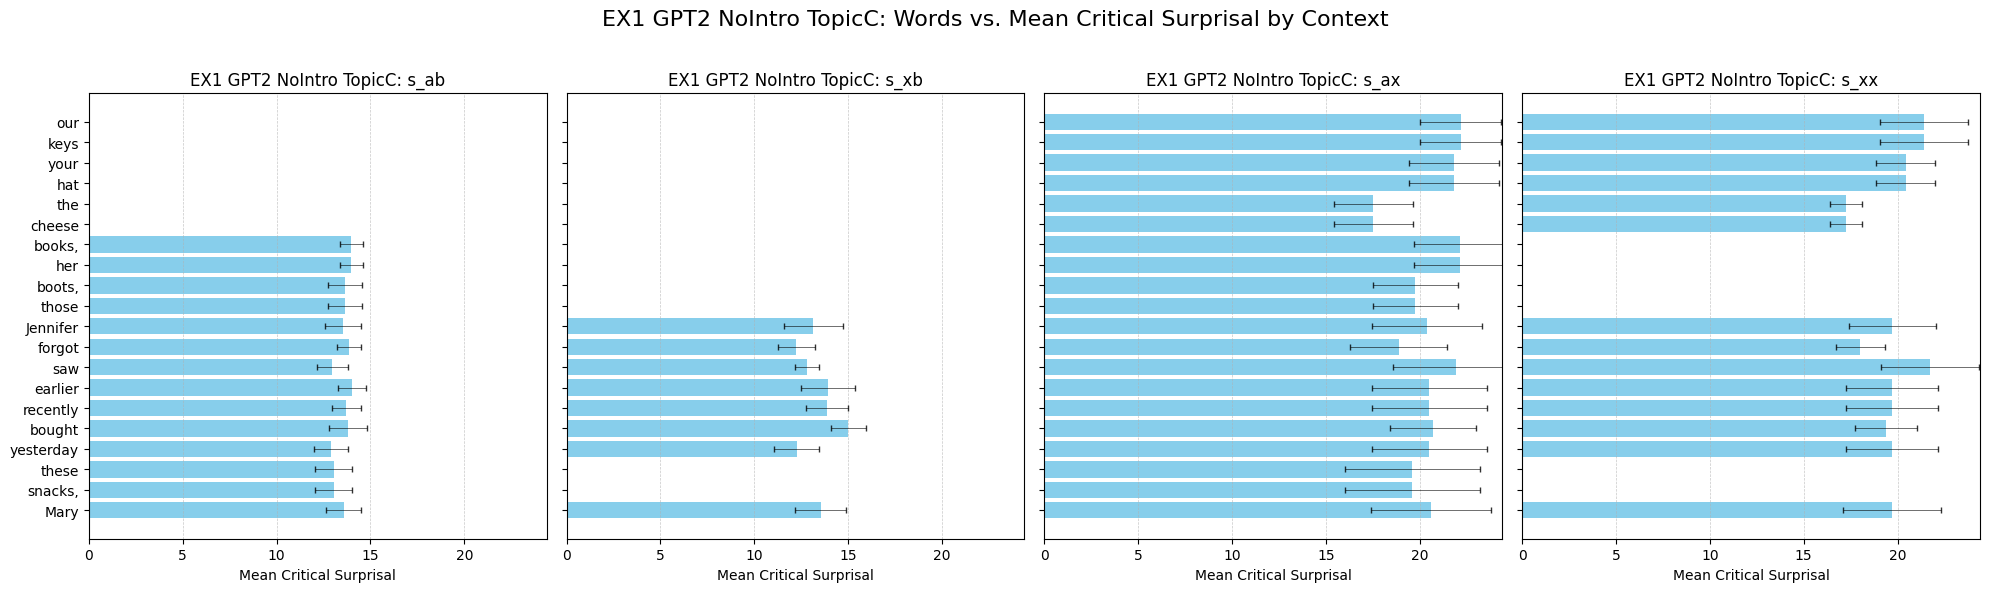

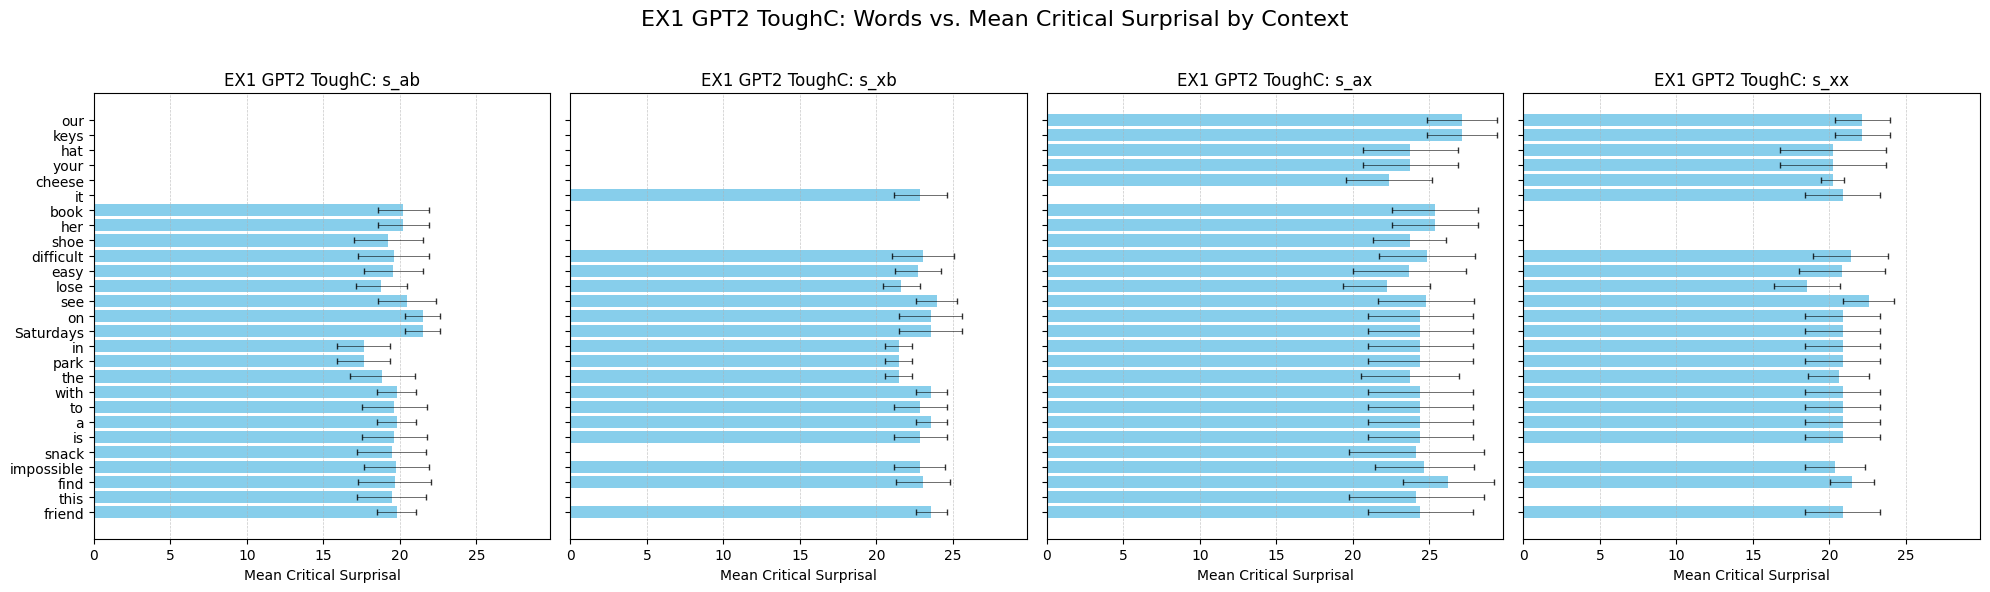

In [8]:
# remarkably little variance between words for this set.
plot_word_stats(itemwise_analyze_json("../grammar_outputs/experiment1/gpt2/cleft_grammar_c.json"), "EX1 GPT2 CleftC")
plot_word_stats(itemwise_analyze_json("../grammar_outputs/experiment1/gpt2/intro_topic_grammar_c.json"), "EX1 GPT2 Intro TopicC")
plot_word_stats(itemwise_analyze_json("../grammar_outputs/experiment1/gpt2/nointro_topic_grammar_c.json"), "EX1 GPT2 NoIntro TopicC")
plot_word_stats(itemwise_analyze_json("../grammar_outputs/experiment1/gpt2/tough_grammar_c.json"), "EX1 GPT2 ToughC")


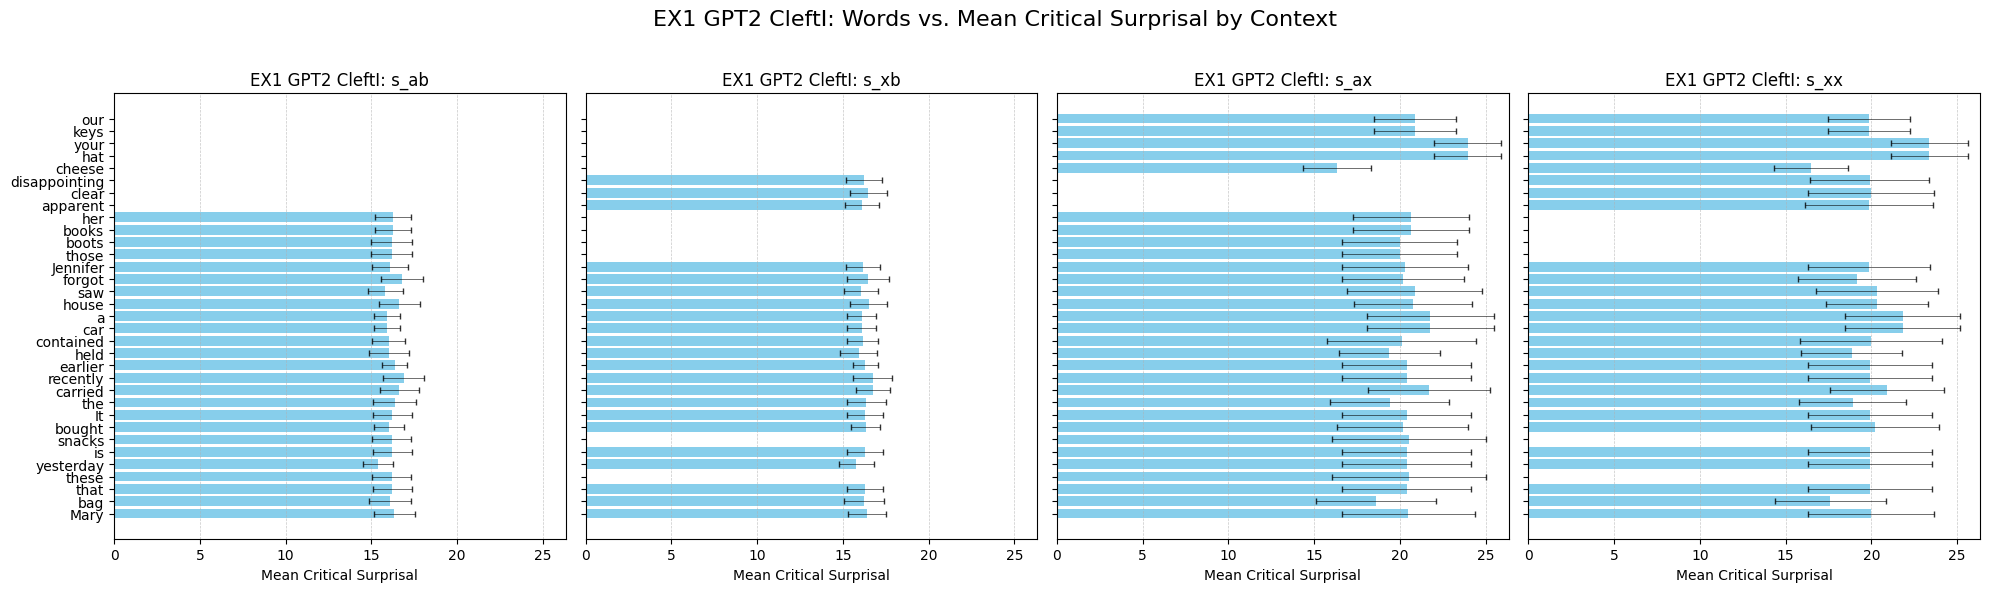

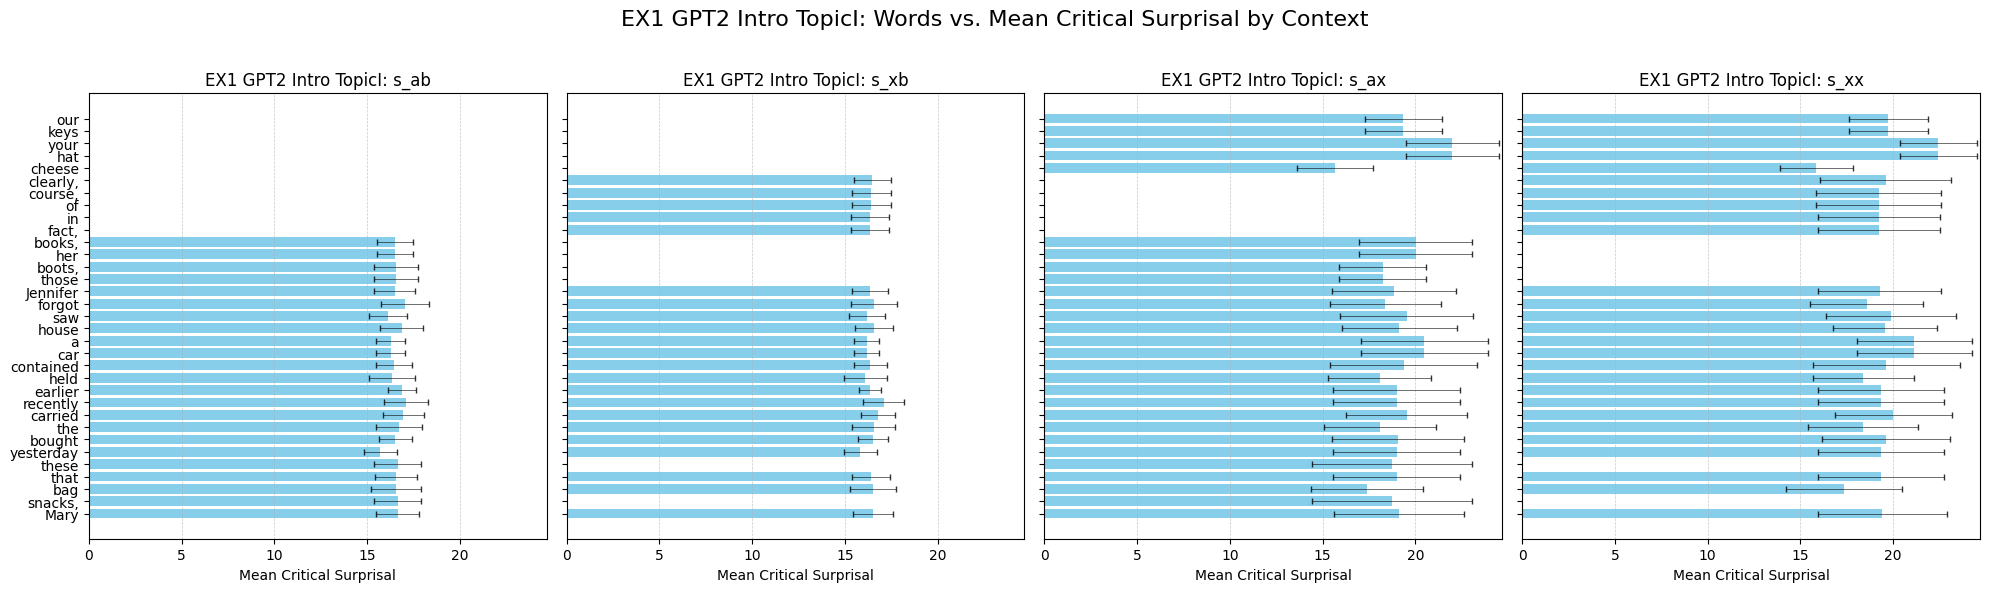

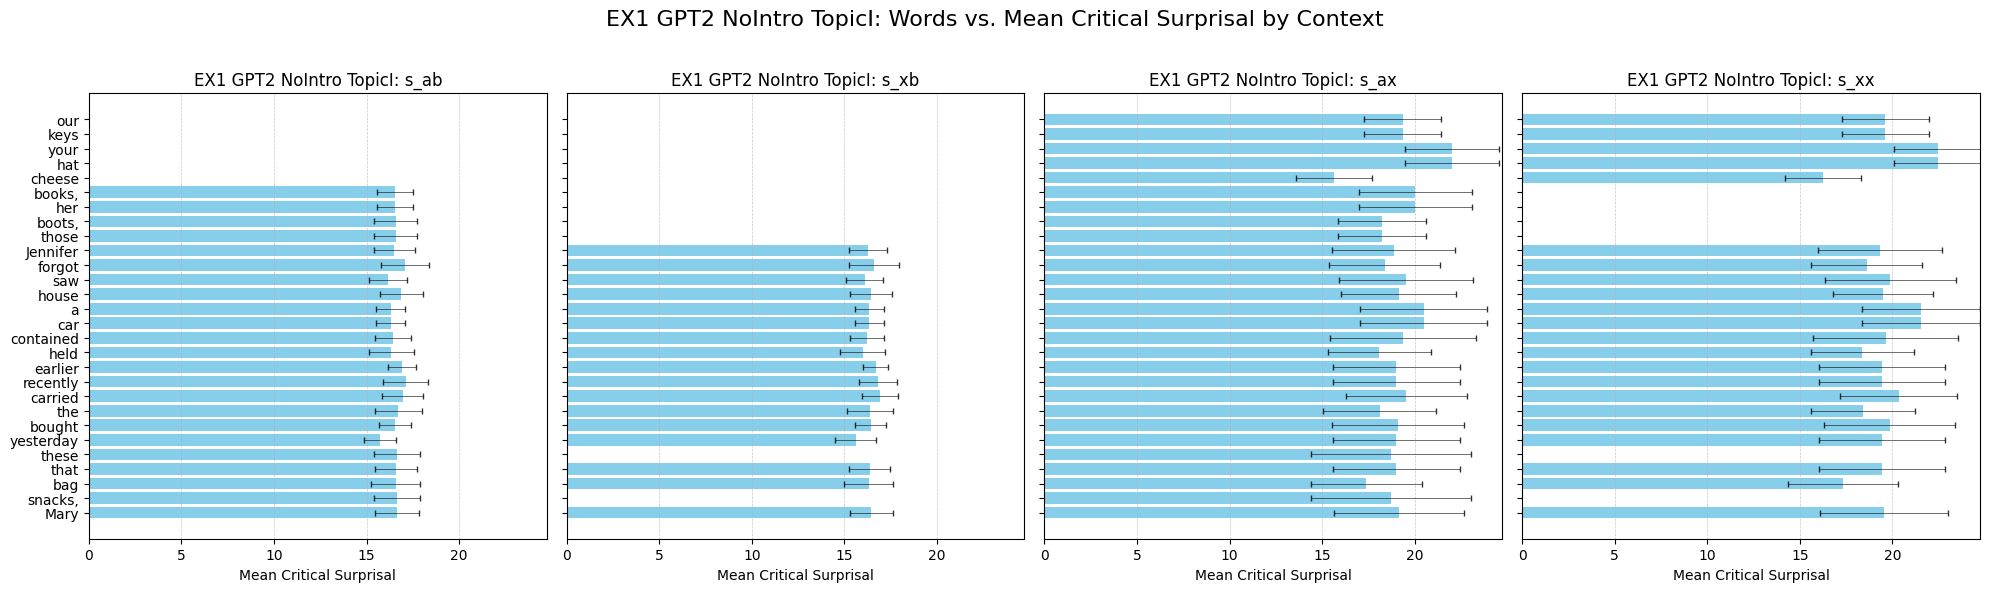

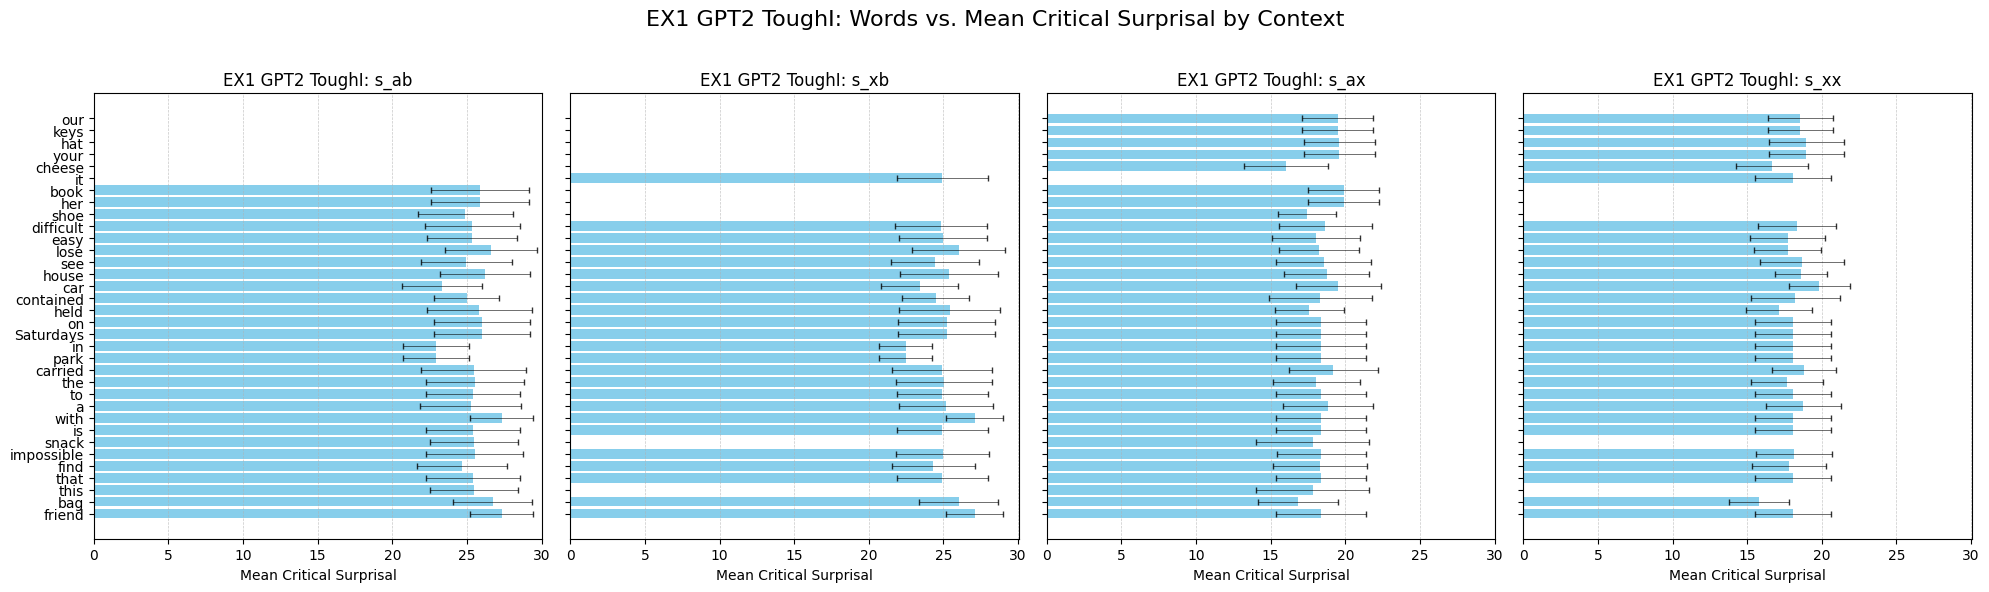

In [9]:
# still, little variance between words for this set. Seems like the structure of the sentences is really what's doing it. 
plot_word_stats(itemwise_analyze_json("../grammar_outputs/experiment1/gpt2/cleft_grammar_i.json"), "EX1 GPT2 CleftI")
plot_word_stats(itemwise_analyze_json("../grammar_outputs/experiment1/gpt2/intro_topic_grammar_i.json"), "EX1 GPT2 Intro TopicI")
plot_word_stats(itemwise_analyze_json("../grammar_outputs/experiment1/gpt2/nointro_topic_grammar_i.json"), "EX1 GPT2 NoIntro TopicI")
plot_word_stats(itemwise_analyze_json("../grammar_outputs/experiment1/gpt2/tough_grammar_i.json"), "EX1 GPT2 ToughI")
